# День 08. Упражнение 03
# Переобучение

## 0. Импорты

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from joblib import dump, load
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

dayofweek = '../ex02/dayofweek.csv'

## 1. Предобработка

1. Прочитай файл `dayofweek.csv` в DataFrame.
2. Используя `train_test_split` с параметрами `test_size=0.2`, `random_state=21`, получи `X_train`, `y_train`, `X_test`, `y_test`.
3. С помощью, например, `value_counts()` проверь, похожее ли распределение классов в train и test.
4. Добавь параметр `stratify=` и проверь распределение снова — теперь оно должно быть более-менее одинаковым в обоих наборах данных.

In [2]:
df = pd.read_csv(dayofweek, index_col=0)

In [3]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

In [5]:
y_train.value_counts(normalize=True)

dayofweek
3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: proportion, dtype: float64

In [6]:
y_train.value_counts(normalize=True)

dayofweek
3    0.234421
6    0.211424
1    0.162463
5    0.160979
2    0.088279
0    0.080861
4    0.061573
Name: proportion, dtype: float64

In [7]:
y_test.value_counts(normalize=True)

dayofweek
3    0.236686
6    0.210059
1    0.162722
5    0.159763
2    0.088757
0    0.079882
4    0.062130
Name: proportion, dtype: float64

## 2. Базовые модели

1. Обучи те же самые базовые модели из предыдущего упражнения и вычисли accuracy, используя тестовый набор данных со стратификацией.
2. Все ли модели показали похожие значения метрики? Какая из них показала наибольшее отличие по сравнению с предыдущим упражнением? Напиши ответ в markdown-ячейке в конце раздела.

### a. Логистическая регрессия

In [8]:
model = OneVsRestClassifier(LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear'))
model.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](43,)","['numTrials','hour','uid_user_0',...,'labname_laba06','labname_laba06s', 'labname_project1']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,43


In [9]:
accuracy = accuracy_score(y_test, model.predict(X_test))
accuracy

0.6153846153846154

### b. SVM

In [10]:
model_svc = OneVsRestClassifier(SVC(kernel="linear", probability=True, random_state=21))
model_svc.fit(X_train, y_train)
accuracy_svc = accuracy_score(y_test, model_svc.predict(X_test))
accuracy_svc

/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probabilit

0.6183431952662722

### c. Дерево решений

In [11]:
model_dtc = DecisionTreeClassifier(max_depth=4, random_state=21)
model_dtc.fit(X_train, y_train)
accuracy_dtc = accuracy_score(y_test, model_dtc.predict(X_test))
accuracy_dtc

0.5295857988165681

### d. Случайный лес

In [12]:
model_rfc = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
model_rfc.fit(X_train, y_train)
accuracy_rfc = accuracy_score(y_test, model_rfc.predict(X_test))
accuracy_rfc

0.9289940828402367

### Случайный лес

## 3. Кросс-валидация

Можно было бы “поиграть” с параметрами модели, чтобы добиться более высокой точности на тестовом наборе, но так делать не принято. Такая тактика снова приводит к переобучению. Тестовый набор предназначен только для финальной проверки качества модели.

Однако есть другой способ решения этой задачи — кросс-валидация. Он не использует тестовый набор, а создает дополнительное разбиение обучающего набора. Существует несколько способов реализации, но общая идея одна: появляется валидационный набор, который используется для подбора гиперпараметров.

1. Используя `cross_val_score` с параметром `cv=10`, вычисли среднее значение accuracy и стандартное отклонение для каждой модели, использованной ранее (логистическая регрессия с `solver='liblinear'`, SVC, дерево решений, случайный лес).

### a. Логистическая регрессия

In [13]:
score = cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy")
score.mean()

np.float64(0.5815975677169707)

### b. SVM

In [14]:
score = cross_val_score(model_svc, X_train, y_train, cv=10, scoring="accuracy")
score.mean()

/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mnemokae/Desktop/School21_projects/DSB10_Intro_to_ML.ID_1577653-1/mnemokae/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probabilit

np.float64(0.5705085682697624)

### c. Дерево решений

In [15]:
score = cross_val_score(model_dtc, X_train, y_train, cv=10, scoring="accuracy")
score.mean()

np.float64(0.5088944168048645)

### d. Случайный лес

In [16]:
score = cross_val_score(model_rfc, X_train, y_train, cv=10, scoring="accuracy")
score.mean()

np.float64(0.9176561636263129)

## 4. Оптимизация

1. Выбери лучшую модель и немного поиграй с её параметрами на кросс-валидации, чтобы найти достаточно хорошие параметры или их комбинацию.
2. Вычисли accuracy для финальной модели на тестовом наборе данных.
3. Построй график, отображающий 10 самых важных признаков для этой модели.
4. Сохрани модель с помощью `joblib`.
5. Загрузи модель, сделай предсказания для тестового набора и вычисли accuracy.

In [17]:
depths = [5, 10, 15, 20, 25, 30]
best = {"depth": 0, "estimators": 0, "accuracy": 0}
for depth in depths:
    estimators = [50, 75, 100, 125, 150]
    for estimator in estimators:
        test_model = RandomForestClassifier(
            n_estimators=estimator, max_depth=depth, random_state=21
        )
        score = cross_val_score(test_model, X_train, y_train, cv=10, scoring="accuracy")
        accuracy = score.mean()
        if accuracy > best["accuracy"]:
            best["accuracy"] = accuracy
            best["depth"] = depth
            best["estimators"] = estimator

for key, value in best.items():
    print(f"{key}: {value}")

depth: 25
estimators: 100
accuracy: 0.9176561636263129


In [18]:
best_model = RandomForestClassifier(
    n_estimators=best["estimators"],
    max_depth=best["depth"],
    random_state=21
)
best_model.fit(X_train, y_train)
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
test_accuracy

0.9289940828402367

In [19]:
def plot_top_features(importance, feature_names, top_n=10):
    sorted_idx = np.argsort(np.abs(importance))[::-1][:top_n]
    top_importance = importance[sorted_idx]
    top_names = np.array(feature_names)[sorted_idx]
    
    colors = ['red' if c > 0 else 'blue' for c in top_importance]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_importance)), top_importance, color=colors)
    plt.yticks(range(len(top_importance)), top_names)
    plt.xlabel('Coefficient value')
    plt.title(f'Top-{top_n} most important features')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

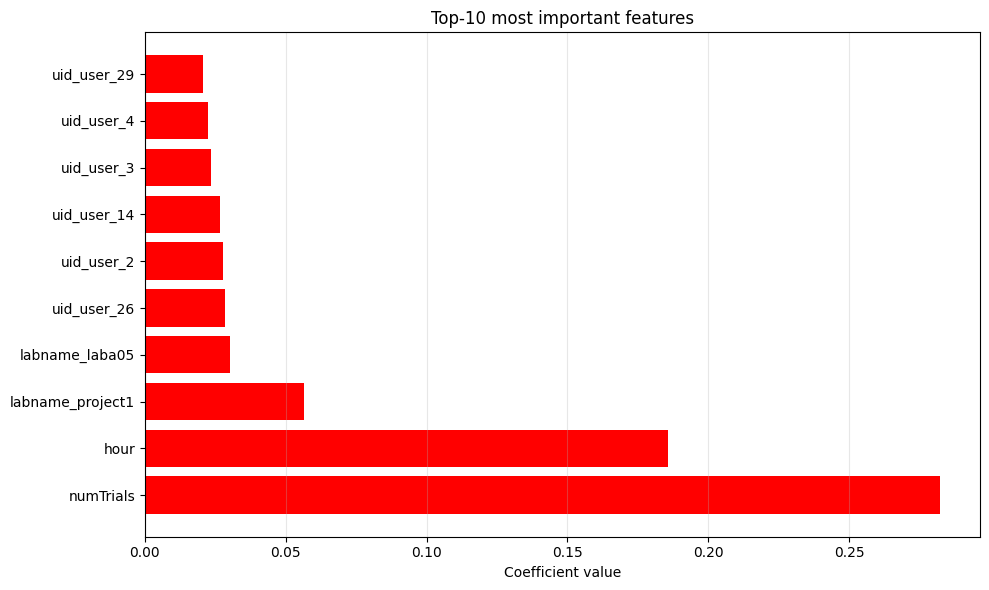

In [20]:
importances = best_model.feature_importances_

plot_top_features(importances, X.columns, 10)

In [21]:
dump(best_model, 'model.pkl')

['model.pkl']

In [22]:
loaded_model = load('model.pkl')

In [23]:
predictions = loaded_model.predict(X_test)
accuracy_loaded = accuracy_score(y_test, predictions)
accuracy_loaded

0.9289940828402367